In [1]:
!pip install ultralytics supervision opencv-python tqdm lap

In [13]:
import cv2
import numpy as np
import supervision as sv
from ultralytics import YOLO
from tqdm.notebook import tqdm
import time
import os
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt
import matplotlib.image as mpimg



In [20]:
# ── Paths ──────────────────────────────────────────────────────────────────
SOURCE_VIDEO_PATH = r"C:\mine\ai adv diploma\speeding cars project\vehicles.mp4"
TARGET_VIDEO_PATH = r"C:\mine\ai adv diploma\speeding cars project\output.mp4"
SNAPSHOTS_DIR     = r"C:\mine\ai adv diploma\speeding cars project\snapshots"

# Options: 'yolov8n.pt' (fastest), 'yolov8s.pt' (good balance), 'yolov8m.pt', 'yolov8x.pt'
MODEL_PATH = "yolov8x.pt"   # 🔥 MUCH faster than yolo11x

# ── Speed threshold ────────────────────────────────────────────────────────
SPEED_LIMIT    = 90     # km/h

# ── Far-car (fix) filter ────────────────────────────────────────────────────────
SPEED_ZONE_MIN_Y = 660  # Only process cars below this Y pixel value
ALERT_DURATION = 2.0    # seconds
SMOOTH_WINDOW  = 5      # speed averaging window

# ── Speed scale correction ─────────────────────────────────────────────────
SPEED_SCALE = 1.0

# ── Perspective calibration (points of the road estimated)────────────────────────────────────────────────
SOURCE = np.array([
    [1252, 787],   # bottom-left
    [ 241, 787],   # bottom-right
    [ 601, 469],   # top-right
    [1030, 469],   # top-left
], dtype=np.float32)

TARGET_WIDTH  = 8      # metres
TARGET_HEIGHT = 280    # metres

TARGET = np.array([
    [          0, TARGET_HEIGHT],
    [TARGET_WIDTH, TARGET_HEIGHT],
    [TARGET_WIDTH,             0],
    [          0,             0],
], dtype=np.float32)

os.makedirs(SNAPSHOTS_DIR, exist_ok=True)

print(f'   Model          : {MODEL_PATH}')
print(f'   Speed limit    : {SPEED_LIMIT} km/h')
print(f'   TARGET_HEIGHT  : {TARGET_HEIGHT} m')

   Model          : yolov8x.pt
   Speed limit    : 90 km/h
   TARGET_HEIGHT  : 280 m


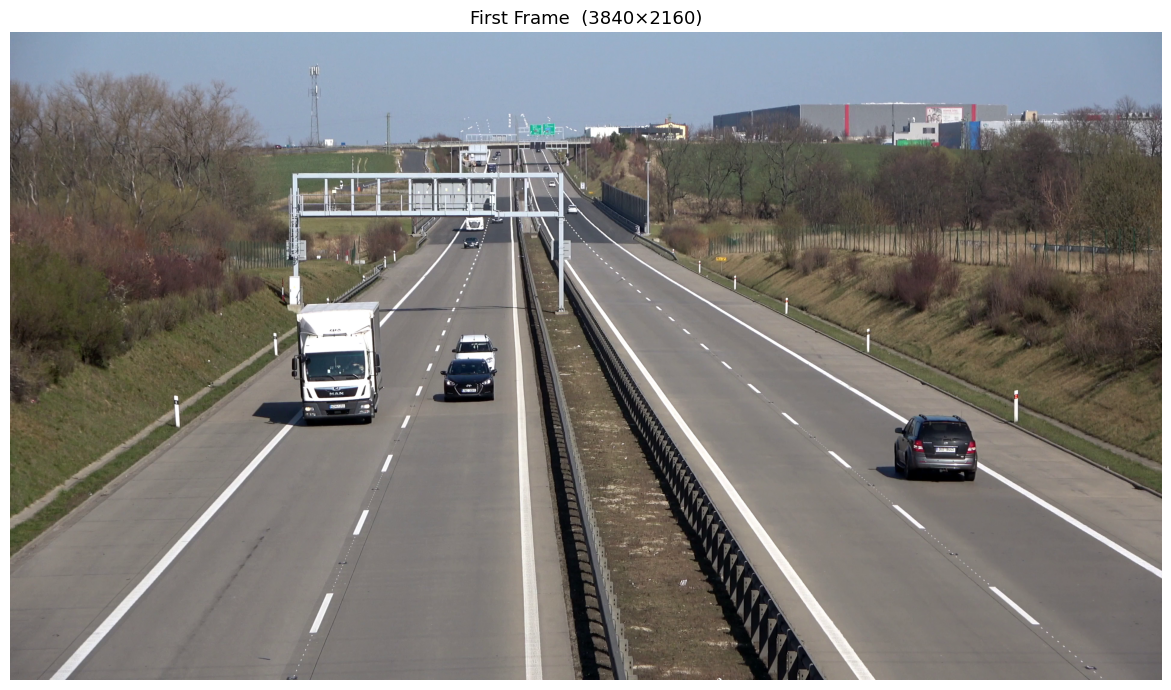

✅ Frame loaded.


In [21]:
# ──  Plain first-frame preview ───────────────────────────────────
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError('❌ Could not read video. Check SOURCE_VIDEO_PATH.')

rgb_frame = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
h_f, w_f  = first_frame.shape[:2]

plt.figure(figsize=(14, 7))
plt.imshow(rgb_frame)
plt.title(f'First Frame  ({w_f}×{h_f})', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()
print('✅ Frame loaded.')

In [22]:
class ViewTransformer:
    """
    Converts pixel coordinates to real-world coordinates using homography.
    """
    def __init__(self, source: np.ndarray, target: np.ndarray):
        self.m, status = cv2.findHomography(source, target)
        if self.m is None:
            raise ValueError('Homography could not be computed.')
        print(f'✅ ViewTransformer ready')

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        if len(points) == 0:
            return points
        pts = points.reshape(-1, 1, 2).astype(np.float32)
        transformed = cv2.perspectiveTransform(pts, self.m)
        return transformed.reshape(-1, 2)

view_transformer = ViewTransformer(source=SOURCE, target=TARGET)

✅ ViewTransformer ready


In [23]:
model = YOLO(MODEL_PATH)

# Normal detections (green)
box_ann   = sv.BoxAnnotator(thickness=4,  color=sv.Color.GREEN)
lab_ann   = sv.LabelAnnotator(text_thickness=2, text_scale=1.0,
                               text_padding=15,  color=sv.Color.GREEN)
# Speeding / alert detections (red)
alert_box_ann = sv.BoxAnnotator(thickness=6,  color=sv.Color.RED)
alert_lab_ann = sv.LabelAnnotator(text_thickness=3, text_scale=1.2,
                                   text_padding=20,  color=sv.Color.RED)
# Motion trail
trace_ann = sv.TraceAnnotator(thickness=2, trace_length=30)

print('✅ Annotators ready')

✅ Annotators ready


In [25]:
import cv2
import os
import time
import numpy as np
import supervision as sv
from ultralytics import YOLO
from tqdm import tqdm

# ✅ NEW FUNCTION: Calculate depth-corrected speed
def calculate_speed_with_depth_correction(p1, p2, pixel_y, elapsed_sec, fps):
    """
    Calculate vehicle speed with perspective depth correction.
    
    The key insight: Far cars (low Y pixel values) have inflated speeds because
    perspective transformation amplifies their movement. We correct this by:
    1. Calculating a depth factor based on Y position in frame
    2. Applying stronger correction for cars farther from camera (smaller Y)
    
    Args:
        p1, p2: Start and end positions in transformed (real-world) coordinates
        pixel_y: Y pixel coordinate of the car (bottom center anchor)
        elapsed_sec: Time elapsed between p1 and p2
        fps: Video frames per second
    
    Returns:
        speed in km/h with depth correction applied
    """
    if elapsed_sec <= 0:
        return 0.0
    
    # Calculate raw distance in transformed coordinates
    dist = float(np.linalg.norm(p2 - p1))
    
    # ✅ DEPTH CORRECTION FACTOR
    # The farther from camera (smaller Y), the more we need to reduce the calculated speed
    # This is because perspective makes far objects appear to move faster in transformed space
    
    # Define the Y range in your video
    BOTTOM_Y = 787  # Cars closest to camera (your SOURCE bottom points)
    TOP_Y = 469     # Cars farthest from camera (your SOURCE top points)
    
    # Normalize Y position (0 = far, 1 = close)
    if BOTTOM_Y - TOP_Y != 0:
        normalized_y = (pixel_y - TOP_Y) / (BOTTOM_Y - TOP_Y)
        normalized_y = np.clip(normalized_y, 0, 1)  # Keep in [0, 1] range
    else:
        normalized_y = 1.0
    
    # ✅ DEPTH CORRECTION: Apply exponential scaling
    # Far cars (normalized_y near 0) get strong correction
    # Close cars (normalized_y near 1) get minimal correction
    # The exponent controls how aggressive the correction is
    depth_correction = 0.2 + (0.8 * normalized_y**2)
    
    # Apply correction to distance
    corrected_dist = dist * depth_correction
    
    # Calculate speed in km/h
    speed_mps = corrected_dist / elapsed_sec
    speed_kmh = speed_mps * 3.6 * SPEED_SCALE
    
    return speed_kmh

# ── Per-tracker state ──────────────────────────────────────────────────────
coordinates = {}      # tracker_id -> list of (frame_idx, transformed_pos, pixel_y)
alert_timers = {}     # tracker_id -> alert-expiry timestamp
snapped_ids = set()   # tracker IDs already photographed
speed_history = {}    # tracker_id -> list of recent speed readings

frame_gen  = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
fps = video_info.fps

# Minimum frames to accumulate before estimating speed
MIN_HISTORY_FRAMES = max(int(fps * 0.5), 2)

print(f'Video: {video_info.total_frames} frames | {fps:.1f} fps | {video_info.width}x{video_info.height}')
print(f'Speed scale: {SPEED_SCALE}x | TARGET_HEIGHT: {TARGET_HEIGHT} m')
print('Starting processing…\n')

# ── Main Processing Loop ───────────────────────────────────────────────────
with sv.VideoSink(target_path=TARGET_VIDEO_PATH, video_info=video_info) as sink:

    for frame_idx, frame in enumerate(tqdm(frame_gen, total=video_info.total_frames, desc='Processing')):

        # 1. Detect + Track
        results = model.track(
            frame, imgsz=640, conf=0.3,
            persist=True, tracker='bytetrack.yaml', verbose=False
        )[0]
        detections = sv.Detections.from_ultralytics(results)

        
        detections = detections[np.isin(detections.class_id, [2, 5, 7])]

        if len(detections) == 0 or detections.tracker_id is None:
            sink.write_frame(frame)
            continue

        # 2. Transform anchor points to real-world coords
        points = detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
        transformed_points = view_transformer.transform_points(points=points)

        labels = []
        is_alert = np.zeros(len(detections), dtype=bool)
        current_timestamp = time.time()

        for i, tracker_id in enumerate(detections.tracker_id):
            if tracker_id not in coordinates:
                coordinates[tracker_id] = []

            anchor_y = points[i][1] 
            if anchor_y < SPEED_ZONE_MIN_Y:
                labels.append(f'ID:{tracker_id}')
                continue

            #  for depth correction
            coordinates[tracker_id].append((frame_idx, transformed_points[i], anchor_y))

            # Keep 3 seconds of history
            max_history = int(fps * 3)
            if len(coordinates[tracker_id]) > max_history:
                coordinates[tracker_id] = coordinates[tracker_id][-max_history:]

            if len(coordinates[tracker_id]) >= MIN_HISTORY_FRAMES:
                old_frame_idx, p1, old_y = coordinates[tracker_id][0]
                cur_frame_idx, p2, cur_y = coordinates[tracker_id][-1]

                elapsed_sec = (cur_frame_idx - old_frame_idx) / fps
                if elapsed_sec <= 0:
                    labels.append(f'ID:{tracker_id} …')
                    continue

                # ✅ NEW: Use depth-corrected speed calculation
                avg_y = (old_y + cur_y) / 2  # Use average Y position
                raw_speed = calculate_speed_with_depth_correction(
                    p1, p2, avg_y, elapsed_sec, fps
                )

                # Smoothing
                if tracker_id not in speed_history:
                    speed_history[tracker_id] = []
                
                if raw_speed < 250:  # Outlier rejection
                    speed_history[tracker_id].append(raw_speed)
                
                speed_history[tracker_id] = speed_history[tracker_id][-SMOOTH_WINDOW:]
                speed = float(np.mean(speed_history[tracker_id])) if speed_history[tracker_id] else raw_speed

                # 3. Alert & Snapshot Logic
                if speed > SPEED_LIMIT:
                    alert_timers[tracker_id] = current_timestamp + ALERT_DURATION

                    if tracker_id not in snapped_ids:
                        snapped_ids.add(tracker_id)
                        
                        # Take Photo
                        x1, y1, x2, y2 = map(int, detections.xyxy[i])
                        margin = 30
                        h, w = frame.shape[:2]
                        crop = frame[max(0, y1-margin):min(h, y2+margin), max(0, x1-margin):min(w, x2+margin)].copy()
                        
                        snap_name = f'capture_id{tracker_id}_{int(speed)}kmh.jpg'
                        cv2.imwrite(os.path.join(SNAPSHOTS_DIR, snap_name), crop)
                        tqdm.write(f'📸 Snapshot → {snap_name}')

                # 4. Determine Label and Alert State
                if tracker_id in alert_timers and current_timestamp < alert_timers[tracker_id]:
                    is_alert[i] = True
                    labels.append(f'⚠ CAPTURED ID:{tracker_id} | {int(speed)} km/h')
                else:
                    labels.append(f'ID:{tracker_id} {int(speed)} km/h')
            else:
                labels.append(f'ID:{tracker_id} collecting…')

        # 5. Annotate & Write
        annotated_frame = frame.copy()
        
        # Draw Traces
        annotated_frame = trace_ann.annotate(scene=annotated_frame, detections=detections)

        # Draw Normal
        normal_dets = detections[~is_alert]
        normal_labs = [l for l, a in zip(labels, is_alert) if not a]
        if len(normal_dets) > 0:
            annotated_frame = box_ann.annotate(scene=annotated_frame, detections=normal_dets)
            annotated_frame = lab_ann.annotate(scene=annotated_frame, detections=normal_dets, labels=normal_labs)

        # Draw Alerts
        alert_dets = detections[is_alert]
        alert_labs = [l for l, a in zip(labels, is_alert) if a]
        if len(alert_dets) > 0:
            annotated_frame = alert_box_ann.annotate(scene=annotated_frame, detections=alert_dets)
            annotated_frame = alert_lab_ann.annotate(scene=annotated_frame, detections=alert_dets, labels=alert_labs)

        sink.write_frame(annotated_frame)

print(f'\n✅ Done!')
print(f'   Output video : {TARGET_VIDEO_PATH}')
print(f'   Snapshots    : {SNAPSHOTS_DIR}')
print(f'   Captured IDs : {len(snapped_ids)} → {sorted(snapped_ids)}')

Video: 538 frames | 25.0 fps | 3840x2160
Speed scale: 1.0x | TARGET_HEIGHT: 280 m
Starting processing…



Processing:   2%|█▋                                                                   | 13/538 [00:08<05:11,  1.69it/s]

📸 Snapshot → capture_id16_97kmh.jpg
📸 Snapshot → capture_id17_94kmh.jpg
📸 Snapshot → capture_id18_103kmh.jpg


Processing:   9%|██████                                                               | 47/538 [00:28<04:47,  1.71it/s]

📸 Snapshot → capture_id27_103kmh.jpg


Processing:  74%|██████████████████████████████████████████████████▏                 | 397/538 [03:59<01:29,  1.57it/s]

📸 Snapshot → capture_id51_126kmh.jpg


Processing: 100%|████████████████████████████████████████████████████████████████████| 538/538 [05:27<00:00,  1.64it/s]


✅ Done!
   Output video : C:\mine\ai adv diploma\speeding cars project\output.mp4
   Snapshots    : C:\mine\ai adv diploma\speeding cars project\snapshots
   Captured IDs : 5 → [np.int32(16), np.int32(17), np.int32(18), np.int32(27), np.int32(51)]


Found 5 snapshot(s):



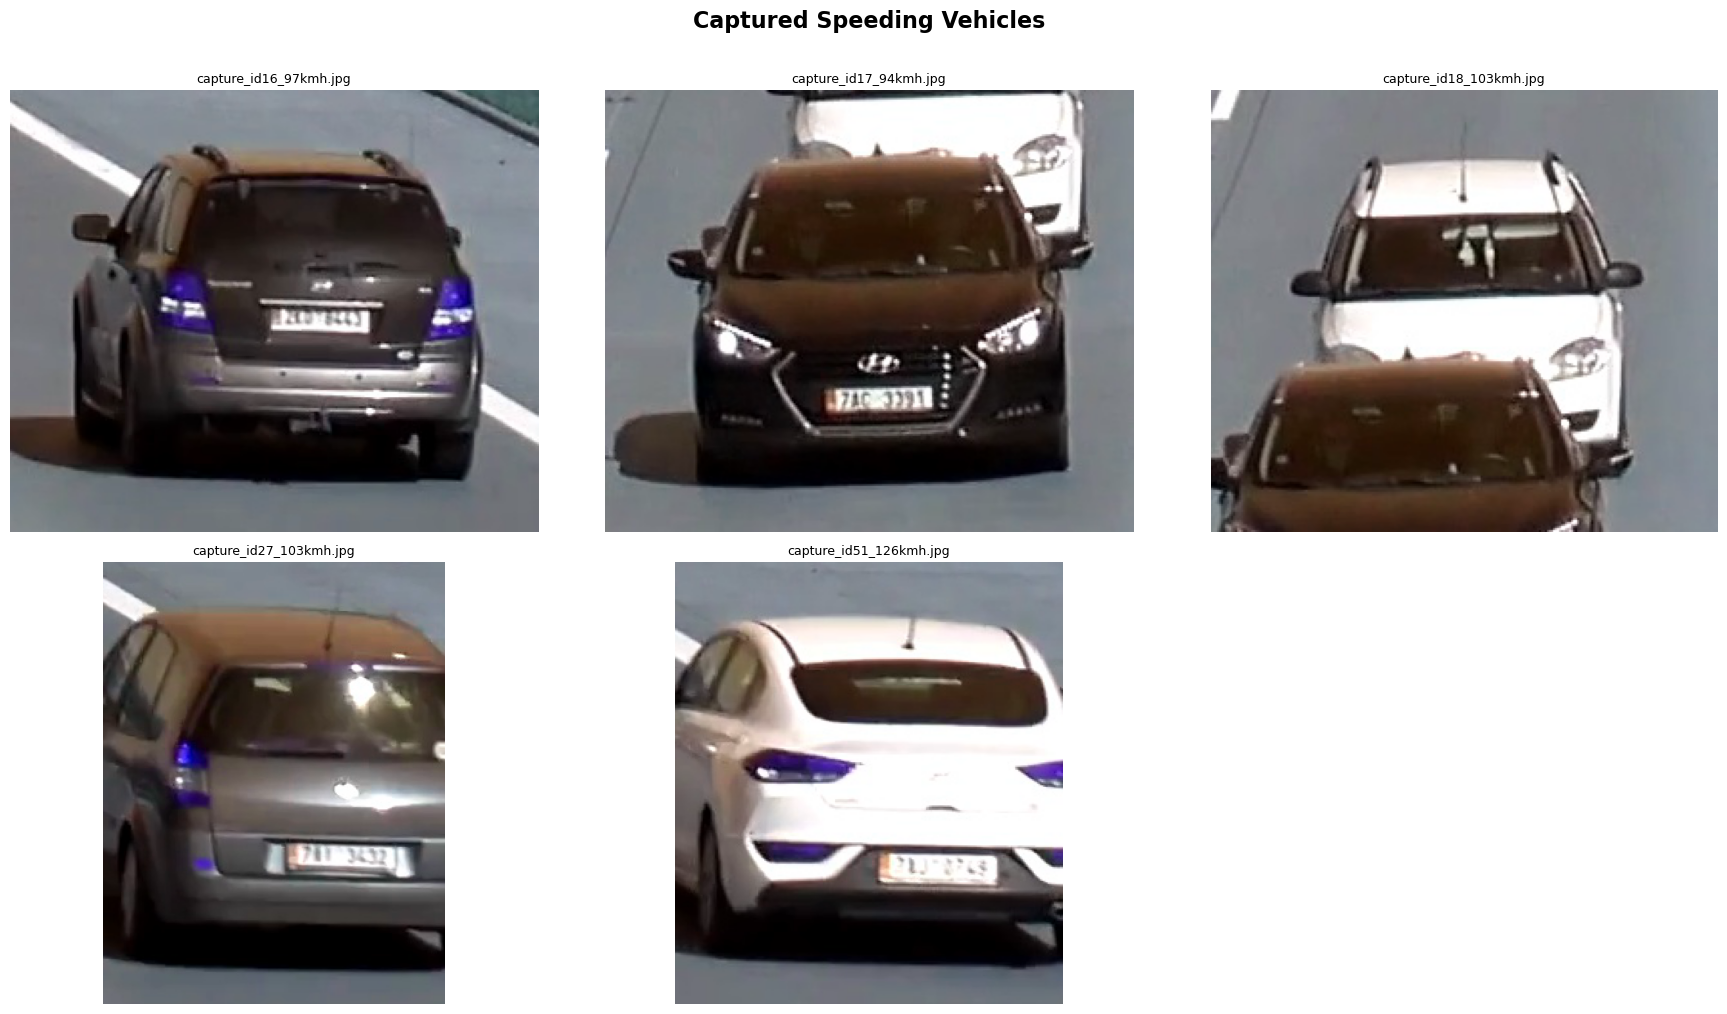

In [26]:
snap_files = sorted([
    f for f in os.listdir(SNAPSHOTS_DIR)
    if f.lower().endswith(('.jpg', '.png'))
])

if not snap_files:
    print('No snapshots found — no vehicles exceeded the speed limit.')
else:
    print(f'Found {len(snap_files)} snapshot(s):\n')
    cols      = 3
    rows      = (len(snap_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes      = np.array(axes).flatten()

    for idx, fname in enumerate(snap_files):
        img  = mpimg.imread(os.path.join(SNAPSHOTS_DIR, fname))
        if img.ndim == 3 and img.shape[2] == 3:
            img = img[:, :, ::-1]
        axes[idx].imshow(img)
        axes[idx].set_title(fname, fontsize=9, wrap=True)
        axes[idx].axis('off')

    for idx in range(len(snap_files), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Captured Speeding Vehicles', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()